In [1]:
%cd /home/anw2067/visualnav-transformer/train
import argparse
from datetime import datetime
import os
import torch
import yaml
import copy
import wandb
import json
import random


from nymeria.download_utils import DownloadManager
from nymeria.definitions import DataGroups
from nymeria.data_provider import SequencePathProvider, NymeriaDataProvider
from nymeria.definitions import Subpaths, VrsFiles
from nymeria.recording_data_provider import create_recording_data_provider

import numpy as np
from torchvision import transforms
from dreamsim import dreamsim
from scipy.spatial.transform import Rotation as R
from torch.utils.data import DistributedSampler, RandomSampler, DataLoader
from diffusers.models import AutoencoderKL

from peva.models import CDiT_models
from peva.diffusion import create_diffusion

from vint_train.training.nymeria_training_utils import get_action_smpl_torch
from vint_train.data.misc import XSensConstants, XsensSkeleton
from planning.utils import _compute_pose_and_loss, _compute_part_distance_matrices
from planning.cem import CEMPlanner
from planning.utils import get_nymeria_dataset, load_peva, load_policy
from planning.wrappers import EvaluatorPeva, EvaluatorWaypoint, ObjectiveDreamSIM, PevaWM, Preprocessor, WaypointWM
from planning.sampling import waypoint_sample
from planning.vis_utils import *

from torchvision.utils import save_image

OUTPUT_DIR = "/home/anw2067/visualnav-transformer/train/logs/paper_vis/teaser"
DATA_SAVE_DIR = "/home/anw2067/scratch/nymeria_camera_dir"
DATA_JSON="/home/anw2067/visualnav-transformer/data_jsons/visibility_no_data.json"

os.makedirs(DATA_SAVE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


/home/anw2067/visualnav-transformer/train


/scratch/anw2067/conda/envs/nomad_train2/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
/scratch/anw2067/conda/envs/nomad_train2/lib/python3.10/site-packages/wandb/sdk/internal/internal_api.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/scratch/anw2067/conda/envs/nomad_train2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
GLOBAL_POLICY = None
GLOBAL_POLICY_DIFFUSION = None
GLOBAL_NOMAD_STATS = None
GLOBAL_NOMAD_CONFIG = None
GLOBAL_PEVA_MODEL = None
GLOBAL_PEVA_DIFFUSION = None
GLOBAL_PEVA_VAE = None
GLOBAL_PEVA_STATS = None
GLOBAL_PEVA_CONFIG = None


In [ ]:
def custom_plot(body1, rpy1, body2, rpy2, image, plot_lines_from=[0, 6, 10, 14]):
    """
    Plot the head of the first body and the skeleton of the second body.
    
    Args:
        body1: (1, 15, 3) or (15, 3) - first body xyz positions
        rpy1: (1, 15, 3) or (15, 3) - first body rpy angles
        body2: (1, 15, 3) or (15, 3) - second body xyz positions
        rpy2: (1, 15, 3) or (15, 3) - second body rpy angles (not used, but kept for signature)
        image: (3, H, W) - goal image (not used, but kept for signature)
    
    Returns:
        PIL Image
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    from scipy.spatial.transform import Rotation as R
    from PIL import Image
    import io
    
    # Convert to numpy if torch tensors
    if isinstance(body1, torch.Tensor):
        body1 = body1.detach().cpu().numpy()
    if isinstance(rpy1, torch.Tensor):
        rpy1 = rpy1.detach().cpu().numpy()
    if isinstance(body2, torch.Tensor):
        body2 = body2.detach().cpu().numpy()
    
    # Handle extra dimension if present
    if body1.ndim == 3:
        body1 = body1[0]  # (15, 3)
    if rpy1.ndim == 3:
        rpy1 = rpy1[0]  # (15, 3)
    if body2.ndim == 3:
        body2 = body2[0]  # (15, 3)
    
    # Rotate all data around z-axis by 90 degrees
    # Rotation matrix for 90 degrees around z-axis: [x', y', z'] = [-y, x, z]
    def rotate_z_90(points):
        """Rotate points 90 degrees around z-axis"""
        if points.ndim == 2:
            # (N, 3) -> rotate each point
            rotated = points.copy()
            rotated[:, 0], rotated[:, 1] = -points[:, 1], points[:, 0]
            return rotated
        else:
            # (3,) -> single point
            return np.array([-points[1], points[0], points[2]])
    
    body1 = rotate_z_90(body1)
    body2 = rotate_z_90(body2)
    
    # Create figure
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Remove grid and axes
    # ax.grid(False)
    # ax.xaxis.pane.fill = False
    # ax.yaxis.pane.fill = False
    # ax.zaxis.pane.fill = False
    # ax.xaxis.pane.set_edgecolor('white')
    # ax.yaxis.pane.set_edgecolor('white')
    # ax.zaxis.pane.set_edgecolor('white')
    # ax.set_xticklabels([])
    # ax.set_yticklabels([])
    # ax.set_zticklabels([])
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.set_zticks([])
    # ax.set_axis_off()
    
    # Get head index (Head is at index 6 in upper body parts)
    head_idx = 6
    
    # Plot head of first body
    head_pos = body1[head_idx]  # (3,)
    head_rpy = rpy1[head_idx]  # (3,)
    
    # Convert RPY to rotation matrix
    rot = R.from_euler('xyz', head_rpy, degrees=False)
    rot_matrix = rot.as_matrix()  # (3, 3)
    
    # Plot head position
    ax.scatter(head_pos[0], head_pos[1], head_pos[2], c='r', s=100, marker='o')
    
    # Plot head orientation arrows
    arrow_length = 0.15
    ax.quiver(head_pos[0], head_pos[1], head_pos[2], 
              rot_matrix[0, 0], rot_matrix[1, 0], rot_matrix[2, 0], 
              color='r', length=arrow_length, normalize=True, arrow_length_ratio=0.3)  # +X Forward (Red)
    ax.quiver(head_pos[0], head_pos[1], head_pos[2], 
              rot_matrix[0, 1], rot_matrix[1, 1], rot_matrix[2, 1], 
              color='g', length=arrow_length, normalize=True, arrow_length_ratio=0.3)  # +Y Left (Green)
    ax.quiver(head_pos[0], head_pos[1], head_pos[2], 
              rot_matrix[0, 2], rot_matrix[1, 2], rot_matrix[2, 2], 
              color='b', length=arrow_length, normalize=True, arrow_length_ratio=0.3)  # +Z Up (Blue)
    
    # Plot skeleton of first body
    from vint_train.visualizing.nymeria_utils import plot_trajs_and_points_full_body
    
    # Use only upper body parts for skeleton
    kintree_parents = XSensConstants.kintree_parents[:XSensConstants.upper_body_num_parts]
    color_skeleton = XSensConstants.color_skeleton[:XSensConstants.upper_body_num_parts]
    
    plot_trajs_and_points_full_body(
        ax,
        body1,
        pose_rotmat=None,
        kintree_parents=kintree_parents,
        color_skeleton=color_skeleton,
        size=2
    )
    
    # Plot skeleton of second body
    plot_trajs_and_points_full_body(
        ax,
        body2,
        pose_rotmat=None,
        kintree_parents=kintree_parents,
        color_skeleton=color_skeleton,
        size=2
    )
    
    # Plot image halfway between head of first body and second body
    if image is not None:
        # Get head position of second body (or use center of body2)
        body2_head_pos = body2[head_idx]  # (3,)
        
        # Calculate midpoint between head of body1 and head of body2
        midpoint = (head_pos + body2_head_pos) / 2.0  # (3,)
        
        # Calculate direction vector from body1 head to body2 head
        direction = body2_head_pos - head_pos  # (3,)
        direction_norm = np.linalg.norm(direction)
        if direction_norm > 1e-6:
            direction = direction / direction_norm  # Normalize
        
        # Convert image to numpy if needed
        if isinstance(image, torch.Tensor):
            goal_img_np = image.detach().cpu().numpy()
        else:
            goal_img_np = np.asarray(image)
        
        # Handle different image formats: (3, H, W) or (H, W, 3)
        if goal_img_np.shape[0] == 3:
            goal_img_np = np.transpose(goal_img_np, (1, 2, 0))
        
        # Normalize to [0, 1] if needed
        if goal_img_np.max() > 1.0:
            goal_img_np = goal_img_np / 255.0
        goal_img_np = np.clip(goal_img_np, 0, 1)
        
        # Flip image vertically to correct orientation
        goal_img_np = np.flipud(goal_img_np)
        
        # Create coordinate system for the image plane
        # The image plane should be perpendicular to the direction vector
        # Use the up vector (Z-axis) as a reference, or use a default up if direction is too close to Z
        up_vector = np.array([0, 0, 1])  # Default up
        
        # If direction is too close to up vector, use a different reference
        if abs(np.dot(direction, up_vector)) > 0.9:
            up_vector = np.array([0, 1, 0])  # Use Y-axis as up
        
        # Calculate image plane axes using cross products
        # Right vector (perpendicular to direction and up)
        right_vec = np.cross(direction, up_vector)
        right_vec_norm = np.linalg.norm(right_vec)
        if right_vec_norm > 1e-6:
            right_vec = right_vec / right_vec_norm
        else:
            # Fallback if vectors are parallel
            right_vec = np.array([1, 0, 0])
        
        # Image up vector (perpendicular to direction and right)
        img_up_vec = np.cross(right_vec, direction)
        img_up_vec_norm = np.linalg.norm(img_up_vec)
        if img_up_vec_norm > 1e-6:
            img_up_vec = img_up_vec / img_up_vec_norm
        else:
            img_up_vec = np.array([0, 0, 1])
        
        # Image dimensions
        img_h, img_w = goal_img_np.shape[:2]
        
        # Calculate image size based on distance between bodies
        distance = np.linalg.norm(body2_head_pos - head_pos)
        img_size = distance * 0.4  # Scale image to 40% of the distance
        
        # Create a plane perpendicular to direction vector
        u = np.linspace(-img_size/2, img_size/2, img_w)
        v = np.linspace(-img_size/2, img_size/2, img_h)
        U, V = np.meshgrid(u, v)
        
        # Create plane coordinates in 3D using affine transform
        # The plane is centered at midpoint, with right_vec and img_up_vec as basis
        X = midpoint[0] + U * right_vec[0] + V * img_up_vec[0]
        Y = midpoint[1] + U * right_vec[1] + V * img_up_vec[1]
        Z = midpoint[2] + U * right_vec[2] + V * img_up_vec[2]
        
        # Plot the image as a surface
        ax.plot_surface(X, Y, Z, facecolors=goal_img_np, rstride=1, cstride=1, shade=False, alpha=0.9)
        
        # Draw thin black lines from joints [0, 6, 10, 14] of second body to camera (head of first body)
        # Joint indices: 0=Pelvis, 6=Head, 10=R_Hand, 14=L_Hand
        joint_indices = plot_lines_from
        
        # Define the image plane: plane through midpoint with normal = direction
        plane_normal = direction  # Normal to the plane
        plane_point = midpoint  # Point on the plane
        
        for joint_idx in joint_indices:
            if joint_idx < body2.shape[0]:  # Make sure index is valid
                joint_pos = body2[joint_idx]  # (3,)
                camera_pos = head_pos  # Camera is at head of first body
                
                # Calculate line from joint to camera using parametric form: P(t) = joint_pos + t * (camera_pos - joint_pos)
                # where t goes from 0 (at joint) to 1 (at camera)
                line_vec = camera_pos - joint_pos  # (3,)
                line_length = np.linalg.norm(line_vec)
                
                if line_length > 1e-6:
                    # Find intersection point with image plane
                    # Plane equation: (P - plane_point) . plane_normal = 0
                    # Substitute: (joint_pos + t * line_vec - plane_point) . plane_normal = 0
                    # Solve for t: t = (plane_point - joint_pos) . plane_normal / (line_vec . plane_normal)
                    
                    denom = np.dot(line_vec, plane_normal)
                    if abs(denom) > 1e-6:  # Line is not parallel to plane
                        t = np.dot(plane_point - joint_pos, plane_normal) / denom
                        intersection_point = joint_pos + t * line_vec
                        
                        # Check if intersection is between joint (t=0) and camera (t=1)
                        if 0 <= t <= 1:
                            # Draw line from joint to intersection, then from intersection to camera
                            ax.plot([joint_pos[0], intersection_point[0]], 
                                   [joint_pos[1], intersection_point[1]], 
                                   [joint_pos[2], intersection_point[2]], 
                                   'k-', linewidth=1, alpha=0.7)
                            ax.plot([intersection_point[0], camera_pos[0]], 
                                   [intersection_point[1], camera_pos[1]], 
                                   [intersection_point[2], camera_pos[2]], 
                                   'k-', linewidth=1, alpha=0.7)
                        else:
                            # If intersection is outside segment, just draw direct line
                            ax.plot([joint_pos[0], camera_pos[0]], 
                                   [joint_pos[1], camera_pos[1]], 
                                   [joint_pos[2], camera_pos[2]], 
                                   'k-', linewidth=1, alpha=0.7)
                    else:
                        # Line is parallel to plane, draw direct line
                        ax.plot([joint_pos[0], camera_pos[0]], 
                               [joint_pos[1], camera_pos[1]], 
                               [joint_pos[2], camera_pos[2]], 
                               'k-', linewidth=1, alpha=0.7)
                else:
                    # Joint and camera are at same position, skip
                    pass
    
    # Set equal aspect ratio and reasonable limits
    all_points = np.concatenate([body1, body2], axis=0)
    center = all_points.mean(axis=0)
    max_range = np.abs(all_points - center).max()
    ax.set_xlim(center[0] - max_range, center[0] + max_range)
    ax.set_ylim(center[1] - max_range, center[1] + max_range)
    ax.set_zlim(center[2] - max_range, center[2] + max_range)
    
    # Convert to PIL Image
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0, dpi=100)
    buf.seek(0)
    img = Image.open(buf)
    plt.close(fig)
    
    return img

No visible parts in 20231109_s0_janet_walsh_act3_1uklre-1131
Visualizing 20231110_s0_thomas_brown_act3_pisdac-1387
No visible parts in 20231204_s1_sylvia_joseph_act4_fvzukw-2592
Visualizing 20231019_s0_douglas_martin_act3_rsqq7a-56
No visible parts in 20231005_s0_glenn_richardson_act0_ubz6ea-216
No visible parts in 20231115_s1_andrew_johnson_act6_vol5wd-215
Visualizing 20231018_s0_scott_hutchinson_act3_46oe4h-1008
No visible parts in 20230725_s1_julie_taylor_act2_mnhq5i-2189
Visualizing 20231113_s0_patricia_gutierrez_act6_209mth-4338
No visible parts in 20230706_s1_morgan_terrell_act2_n6v78a-3050
Visualizing 20231027_s1_stacie_cross_act2_kijh3i-753
No visible parts in 20231117_s0_randy_martin_act2_h0cgyy-855
No visible parts in 20230929_s1_alan_burns_act4_zch0c7-1436
No visible parts in 20230814_s1_david_hall_act4_hd5lpz-1812
No visible parts in 20231102_s0_samuel_rogers_act4_m069p6-1752
No visible parts in 20230628_s1_hayley_little_act2_95pn9m-1494
No visible parts in 20231219_s1_eric

KeyboardInterrupt: 

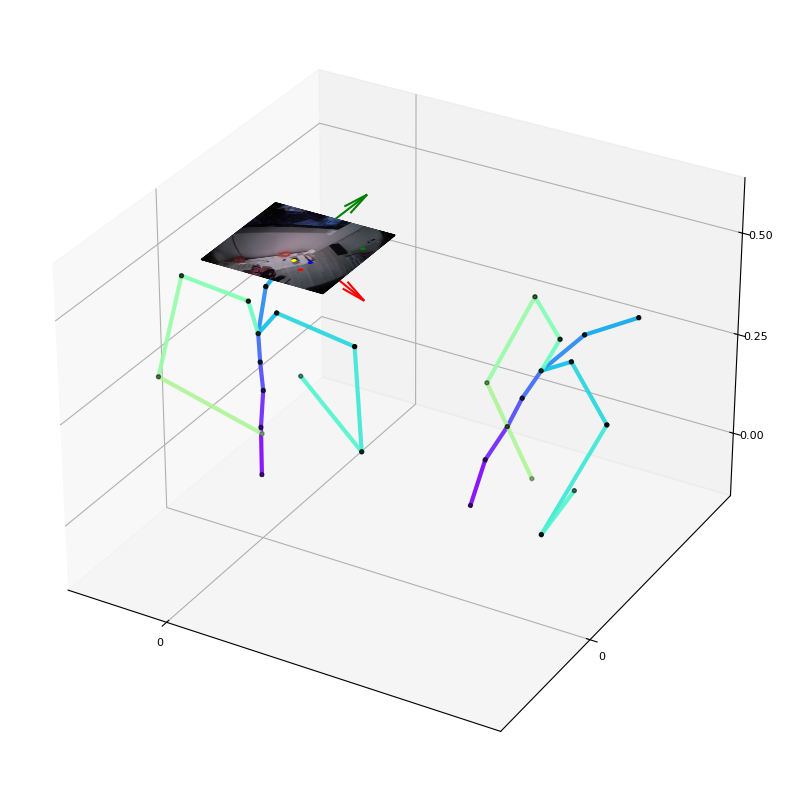

In [18]:
import importlib
import planning.vis_utils
from vint_train.visualizing.nymeria_utils import plot_skeleton
importlib.reload(planning.vis_utils)
from planning.vis_utils import *
import vint_train.data.misc
importlib.reload(vint_train.data.misc)
from vint_train.data.misc import XSensConstants, XsensSkeleton 
from pathlib import Path
disable_logging()

def main(args):
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    global GLOBAL_POLICY, GLOBAL_POLICY_DIFFUSION, GLOBAL_NOMAD_STATS, GLOBAL_NOMAD_CONFIG
    global GLOBAL_PEVA_MODEL, GLOBAL_PEVA_DIFFUSION, GLOBAL_PEVA_VAE, GLOBAL_PEVA_STATS, GLOBAL_PEVA_CONFIG
    if GLOBAL_POLICY is None:
        GLOBAL_POLICY, GLOBAL_POLICY_DIFFUSION, GLOBAL_NOMAD_STATS, GLOBAL_NOMAD_CONFIG = load_policy(args.nomad_config, args.nomad_checkpoint, device=device)
        # GLOBAL_PEVA_MODEL, _, GLOBAL_PEVA_DIFFUSION, GLOBAL_PEVA_VAE, GLOBAL_PEVA_STATS, GLOBAL_PEVA_CONFIG = load_peva(args.peva_config, args.peva_checkpoint, device=device,
        #                                                             inference_context_size=args.peva_context_size,
        #                                                             diffusion_steps=args.peva_diffusion_steps)
    policy, policy_diffusion, nomad_stats, nomad_config = GLOBAL_POLICY, GLOBAL_POLICY_DIFFUSION, GLOBAL_NOMAD_STATS, GLOBAL_NOMAD_CONFIG
    # peva_model, _, peva_diffusion, peva_vae, peva_stats, peva_config = GLOBAL_PEVA_MODEL, None, GLOBAL_PEVA_DIFFUSION, GLOBAL_PEVA_VAE, GLOBAL_PEVA_STATS, GLOBAL_PEVA_CONFIG
    # policy, policy_diffusion, nomad_stats, nomad_config = load_policy(args.nomad_config, args.nomad_checkpoint, device=device)
    # peva_model, _, peva_diffusion, peva_vae, peva_stats, peva_config = load_peva(args.peva_config, args.peva_checkpoint, device=device,
                                                                    # inference_context_size=args.peva_context_size,
                                                                    # diffusion_steps=args.peva_diffusion_steps)
    
    dataset = get_nymeria_dataset(nomad_config, context_size=max(args.peva_context_size-1, nomad_config["context_size"]), goal_timestep_offset=args.goal_timestep_offset)
    sampler = DistributedSampler(dataset, num_replicas=1, rank=0, shuffle=args.shuffle, seed=seed)
    dataloader = DataLoader(dataset, batch_size=1, sampler=sampler, num_workers=1)
    
    count = 0
    prev_track_name = None
    for idx, batch in enumerate(dataloader):
        obs_images = batch["obs_images"] # 1, context_size, 3, H, W
        goal_image = batch["goal_image"] # 1, 3, H, W
        context_poses = batch["context_poses"] # 1, context_size, 48

        deltas = batch["deltas"] # 1, horizon, action_dim
        first_pose = batch["first_pose"] # 1, 1, 48
        xsens_offsets = batch["xsens_offsets"][0] # 1, 15, 3
        goal_obs = batch["goal_obs"] # 1, 3, H, W
        goal_image_coords = batch["goal_image_coords"] # 1, 23, 2
        
        dataset_index = batch["dataset_index"].item()
        track_name, track_index = batch["dataset_track"][0], batch["dataset_track_index"].item()
        track_idx_name = f"{track_name}-{track_index}"
        
        skel = XsensSkeleton(xsens_offsets)
        gt_actions = get_action_smpl_torch(first_pose, deltas, XSensConstants.upper_body_num_parts) # B, T, 48
        xyz_dist_matrix, _, init_xyz, _ = _compute_part_distance_matrices(first_pose[:, -1], gt_actions[:, -1], skel)
        visible_plus_head = (goal_image_coords != -1).all(dim=-1)[:, :XSensConstants.upper_body_num_parts] # B, num_parts
        visible_plus_head[:, XSensConstants.part_names.index("Head")] = True
        init_visible_plus_head = xyz_dist_matrix[:, XSensConstants.leaf_indices] * visible_plus_head[:, XSensConstants.leaf_indices]
        init_visible_plus_head = (init_visible_plus_head.sum() / visible_plus_head.sum()).item()
        
        if not args.keep_nonvisible_goal:
            visible = False
            find_count = 0
            for part in ["Pelvis", "Head", "R_Hand", "L_Hand"]:
                index = XSensConstants.part_names.index(part)
                if all(goal_image_coords[0, index] != -1):
                    find_count += 1
                    if find_count == 4:
                        visible = True
                        break
            if not visible:
                print(f"No visible parts in {track_idx_name}")
                continue
            
        if init_visible_plus_head < args.min_dist_threshold:
            print(f"Initial distance of visible + head joints is less than {args.min_dist_threshold} in {track_idx_name}")
            continue
        print(f"Visualizing {track_idx_name}")
        
        curr_save_dir = f"{OUTPUT_DIR}/{track_idx_name}"
        os.makedirs(curr_save_dir, exist_ok=True)
        save_img = torch.cat([obs_images, goal_obs[None],torch.zeros_like(obs_images[:, :-2]), goal_image[None]], dim=1)[0]
        save_image(save_img, f"{curr_save_dir}/context_and_goal.png", nrow=obs_images.shape[1])
        
        # config details
        policy_pred_horizon = nomad_config["len_traj_pred"]
        policy_action_dim = nomad_config["input_dims"]
        image_size = nomad_config["image_size"][0]
        policy_context_size = nomad_config["context_size"] + 1
        # peva_context_size = peva_config["context_size"]
        peva_latent_size = image_size // 8
        
        waypoints = goal_image_coords[:, XSensConstants.leaf_indices].flatten(1, 2)[:, None] # 1, 4, 2
        policy_context_poses = context_poses[:, -policy_context_size:]
        
        gt_actions = get_action_smpl_torch(first_pose, deltas, XSensConstants.upper_body_num_parts) # B, T, 48
        fp_xyz, fp_rpy = forward_kinematics_wrapper(first_pose, skel, return_euler=True) # (B, 1, 15, 3), (B, 1, 15, 3)
        gt_xyz, gt_rpy = forward_kinematics_wrapper(gt_actions[:, -1:], skel, return_euler=True) # (B, 1, 15, 3), (B, 1, 15, 3)

        pelvis_l2_dist = torch.norm(fp_xyz[0, 0, 0] - gt_xyz[0, 0, 0], dim=-1)
        
        goal_image_np = goal_image.cpu().numpy()[0]  # (3, H, W)
        
        # if track_idx_name != "20231110_s0_thomas_brown_act3_pisdac-1387":
        #     continue
        
        img_dir = "/home/anw2067/visualnav-transformer/train/logs/paper_vis/waypoint_generation_vis/pelvis_distancev6"
        os.makedirs(img_dir, exist_ok=True)
        img = custom_plot(fp_xyz[0], fp_rpy[0], gt_xyz[0], gt_rpy[0], goal_image_np, plot_lines_from=[])
            
        img.save(os.path.join(img_dir, f"{track_idx_name}-dist{pelvis_l2_dist.item():.3f}.png"))
            
        count += 1
        if count > 30:
            break
        
        
MODEL_DIRECTORY={
    "draw": (   
        "/home/anw2067/visualnav-transformer/train/logs/nomad-minimal/2025_12_09_11_24:nomad-minimal-proprioception-cat8-dinov3_unpool_3dposemb-proj-lr5e-4-pool_curr_obs-goaldraw/config.yaml",
        "/home/anw2067/visualnav-transformer/train/logs/nomad-minimal/2025_12_09_11_24:nomad-minimal-proprioception-cat8-dinov3_unpool_3dposemb-proj-lr5e-4-pool_curr_obs-goaldraw/ema_9.pth"
    ),
    "gravity": (
        "/home/anw2067/visualnav-transformer/train/logs/nomad-minimal/2025_12_18_11_47:nomad-minimal-proprioception-cat8-dinov3_unpool_3dposemb-proj-lr5e-4-pool_curr_obs-goaldraw-preserveUpDown/config.yaml",
        "/home/anw2067/visualnav-transformer/train/logs/nomad-minimal/2025_12_18_11_47:nomad-minimal-proprioception-cat8-dinov3_unpool_3dposemb-proj-lr5e-4-pool_curr_obs-goaldraw-preserveUpDown/ema_9.pth"
    ),
    "draw_mask": (
        "/home/anw2067/visualnav-transformer/train/config/torch/minimal-nomad-proprioception-cat8-dinov3_unpool_3dposemb-proj-lr5e-4-pool_curr_obs-goaldraw-waypointMask.yaml",
        "/home/anw2067/visualnav-transformer/train/logs/nomad-minimal/2026_01_21_06_54:nomad-minimal-proprioception-cat8-dinov3_unpool_3dposemb-proj-lr5e-4-pool_curr_obs-goaldraw-waypointMask/ema_9.pth"
    )
}
        
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    
    parser.add_argument("-a", "--algo", type=str, choices=["peva", "waypoint"], default="waypoint", help="Planning algorithm")
    parser.add_argument("--use_leafxyz_as_cost", action='store_true', help="Uses the metric(leaf-xyz) instead of a normal cost_fn")
    parser.add_argument("--goal_timestep_offset", type=int, default=None, help="Goal timestep offset")
    parser.add_argument("--shuffle", action="store_true", help="Shuffle the dataset")
    
    parser.add_argument("--keep_nonvisible_goal", action="store_true", help="Keep non-visible goal in the dataset")
    parser.add_argument("--min_index_goal", type=int, default=0, help="Minimum index of the goal to plan")
    parser.add_argument("--min_dist_threshold", type=float, default=0.1, help="Minimum distance threshold")
    parser.add_argument("--num_samples_to_plan", type=int, default=128, help="Number of samples to plan")
    parser.add_argument("--no_wandb", action="store_true", help="Don't use wandb")
    parser.add_argument("--test", action="store_true", help="Test run")
    
    parser.add_argument("--peva_config", type=str, default="/home/anw2067/visualnav-transformer/train/peva/config/nymeria_rel_concat_embedding_compile_beta095_ar_model_context_16_bs_16_smpl_lowebody_-64to_64_1_goal_emb_relative_xxl.yaml")
    parser.add_argument("--peva_checkpoint", type=str, default="/scratch/anw2067/nymeria_rel_concat_embedding_compile_beta095_ar_model_context_16_bs_16_smpl_lowebody_cancel_scaler_-64to_64_xxl_280_0180000.pth.tar")
    parser.add_argument("--peva_context_size", type=int, default=15, help="PEVA context size")
    parser.add_argument("--peva_diffusion_steps", type=int, default=250, help="PEVA diffusion steps")
    
    parser.add_argument("--nomad_model", type=str, default="draw", choices=["draw", "gravity", "draw_mask"])
    parser.add_argument("--nomad_config", type=str, default=None)
    parser.add_argument("--nomad_checkpoint", type=str, default=None)
    
    parser.add_argument("--world_size", type=int, default=1, help="World size")
    parser.add_argument("--rank", type=int, default=0, help="Rank")
    
    # In Jupyter notebooks, pass arguments as a list to parse_args() instead of using sys.argv
    # Pass an empty list [] to use all defaults, or specify arguments like: ['--shuffle', '--nomad_model', 'draw']
    args = parser.parse_args(["--shuffle", "--nomad_model", "draw_mask", "--peva_context_size", "7"])
    
    if args.nomad_model is not None:
        assert args.nomad_config is None and args.nomad_checkpoint is None
        args.nomad_config, args.nomad_checkpoint = MODEL_DIRECTORY[args.nomad_model]
    else:
        assert args.nomad_config is not None and args.nomad_checkpoint is not None
    
    main(args)